<a href="https://colab.research.google.com/github/rcortes100/wide-binaries/blob/main/QueryTest_don.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Query para las Binarias Abiertas
Versión de Donaldo

In [ ]:
# prompt: install astroquery via pip

!pip install astroquery
!mkdir Tables


In [ ]:
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import time

In [ ]:
tables = []
for i in range(8,15):
    minor = 36028797018963968*i
    major = 36028797018963968*(i+1)
    filename = 'Tables/HEALpix%i.csv'%(i)
    query = ("select source_id,ra,dec,parallax \
          from gaiadr3.gaia_source \
          where source_id between %i and %i"%(minor,major))
    job = Gaia.launch_job_async(query=query,dump_to_file=True,output_file=filename,output_format='csv')
    r = job.get_results()
    print(r.info)
    tables.append(r)
    Gaia.remove_jobs([job.jobid])
    #print(r)

<Table length=1328167>
   name    dtype     class     n_bad 
--------- ------- ------------ ------
source_id   int64       Column      0
       ra float64       Column      0
      dec float64       Column      0
 parallax float64 MaskedColumn 180336



INFO:astroquery:Removed jobs: '['1743639107445O']'.


INFO: Removed jobs: '['1743639107445O']'. [astroquery.utils.tap.core]
<Table length=3000000>
   name    dtype     class     n_bad 
--------- ------- ------------ ------
source_id   int64       Column      0
       ra float64       Column      0
      dec float64       Column      0
 parallax float64 MaskedColumn 351601



INFO:astroquery:Removed jobs: '['1743639195584O']'.


INFO: Removed jobs: '['1743639195584O']'. [astroquery.utils.tap.core]


KeyboardInterrupt: 

In [ ]:
print(tables)

[<Table length=1328167>
    source_id              ra                dec               parallax      
      int64             float64            float64             float64       
------------------ ------------------ ------------------ --------------------
288230380447291392 22.503527312931112  19.48768917524941   0.6125747857297634
288230410511760384  22.51718557265225 19.490628974124537                   --
288230410511760512  22.50090111848875   19.4917298666882  0.24666171598365164
288230552245983104 22.533317661046716 19.505534400469294  0.44500781093574965
288230586605720960  22.50657247232423 19.510394864441935   1.1438528672116413
288230620965071488  22.52213199550402  19.52149631264955    3.370862801536703
288230651029929216 22.473048305374885  19.50290071407158  0.09151522468920646
288230655325360768 22.480764257872547  19.50757142872465   2.2532724742393886
288230685389668224 22.482140736784487 19.508347994265982   2.6658748308440843
               ...                ...   

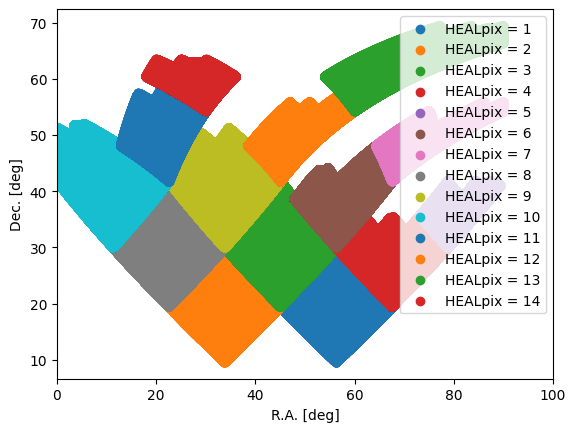

In [ ]:
for i in range(len(tables)):
    r = tables[i]
    plt.scatter(r['ra'],r['dec'],label='HEALpix = %i'%(i+1))

plt.xlabel('R.A. [deg]')
plt.ylabel('Dec. [deg]')
plt.xlim(0,100)
#plt.ylim(29.9,30.1)
plt.legend(loc=1)
plt.savefig('distribucion.png')
plt.show()
plt.close()

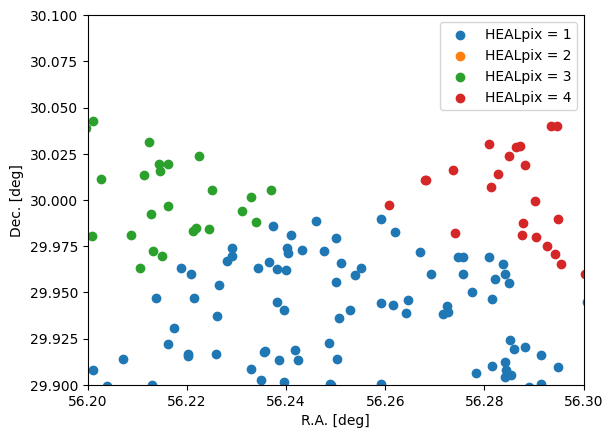

In [ ]:
for i in range(4):
    r = tables[i]
    plt.scatter(r['ra'],r['dec'],label='HEALpix = %i'%(i+1))

plt.xlabel('R.A. [deg]')
plt.ylabel('Dec. [deg]')
plt.xlim(56.2,56.3)
plt.ylim(29.9,30.1)
plt.legend(loc=1)
plt.show()
plt.close()

In [ ]:
start_time = time.time()
for i in range(1,2):
    minor = 36028797018963968*i
    major = 36028797018963968*(i+1)
    query = '''SELECT g3.source_id as source_id3,
 g3.ra as ra3,
 g3.dec as dec3,
 g3.astrometric_chi2_al as astrometric_chi2_al_3,
 g3.astrometric_n_good_obs_al as astrometric_n_good_obs_al3,
 g3.phot_g_mean_flux_over_error as phot_g_mean_flux_over_error3,
 g3.phot_rp_mean_flux_over_error as phot_rp_mean_flux_over_error3,
 g3.phot_bp_mean_flux_over_error as phot_bp_mean_flux_over_error3,
 g3.phot_bp_rp_excess_factor as phot_bp_rp_excess_factor3,
 g3.pmra as pmra3,
 g3.pmra_error as pmra_error3,
 g3.pmdec as pmdec3,
 g3.pmdec_error as pmdec_error3,
 g3.phot_g_mean_mag as phot_g_mean_mag3,
 g3.phot_bp_mean_mag as phot_bp_mean_mag3,
 g3.phot_rp_mean_mag as phot_rp_mean_mag3,
 g3.parallax as parallax3,
 g3.parallax_over_error as parallax_over_error3,
 g3.radial_velocity as radial_velocity3,
 g3.radial_velocity_error as radial_velocity_error3,
 g3.rv_nb_transits as rv_nb_transits3,
 g3.ruwe as ruwe3,
 aspar.classprob_dsc_combmod_binarystar as classprob_dsc_combmod_binarystar3,
 aspar.mass_flame as mass_flame3,
 aspar.mass_flame_lower as mass_flame_lower3,
 aspar.mass_flame_upper as mass_flame_upper3,
 aspar.evolstage_flame as evolstage_flame3,
 t1.source_id, t1.ra, t1.dec, t1.pmra, t1.pmra_error, t1.pmdec,
 t1.pmdec_error, t1.phot_g_mean_mag, t1.phot_bp_mean_mag, t1.phot_rp_mean_mag,
 t1.parallax, t1.parallax_over_error, t1.astrometric_chi2_al,
 t1.astrometric_n_good_obs_al, t1.phot_g_mean_flux_over_error,
 t1.phot_rp_mean_flux_over_error, t1.phot_bp_mean_flux_over_error,
 t1.phot_bp_rp_excess_factor, t1.radial_velocity, t1.radial_velocity_error,
 t1.rv_nb_transits, t1.ruwe, t2.classprob_dsc_combmod_binarystar, t2.mass_flame,
 t2.mass_flame_lower, t2.mass_flame_upper, t2.evolstage_flame,
 distance(POINT('ICRS', t1.ra, t1.dec), POINT('ICRS', g3.ra, g3.dec)) AS pairdistance
FROM (select * from gaiadr3.gaia_source where
 parallax between 5 and 1000 and
 parallax_over_error > 20 and
 phot_g_mean_flux_over_error > 50 and
 phot_rp_mean_flux_over_error > 20 and
 source_id between %i and %i and
 phot_bp_mean_flux_over_error > 20) as t1
 JOIN gaiadr3.astrophysical_parameters as t2
ON t1.source_id=t2.source_id,
 (select * from gaiadr3.gaia_source
 where bp_rp is not null and
 parallax_over_error > 5 and
 phot_g_mean_flux_over_error > 50 and
 phot_rp_mean_flux_over_error > 10 and
 source_id between %i and %i and
 phot_bp_mean_flux_over_error > 10) as g3
JOIN gaiadr3.astrophysical_parameters as aspar
ON g3.source_id=aspar.source_id
WHERE 1 = contains(POINT('ICRS', g3.ra, g3.dec),
 CIRCLE('ICRS', t1.ra, t1.dec, 1.4e-2*t1.parallax))
AND t1.source_id != g3.source_id

AND abs(1/t1.parallax - 1/g3.parallax) - 2*0.01745*distance(POINT('ICRS', t1.ra, t1.dec), POINT('ICRS', g3.ra, g3.dec))/ t1.parallax < 3*sqrt(power(t1.parallax_error, 2)/power(t1.parallax, 4) + power( g3.parallax_error, 2)/power(g3.parallax, 4))

AND sqrt(power((t1.pmra - g3.pmra), 2) + power((t1.pmdec - g3.pmdec), 2)) - (7.42e-3 * power(t1.parallax, 1.5) * power(distance(POINT('ICRS', t1.ra, t1.dec), POINT('ICRS', g3.ra, g3.dec)), -0.5)) < 3*sqrt(((power((t1.pmra_error), 2) + power( (g3.pmra_error), 2)) * power((t1.pmra - g3.pmra), 2) + (power((t1.pmdec_error), 2) + power((g3.pmdec_error), 2)) * power( (t1.pmdec - g3.pmdec), 2))/(power( (t1.pmra - g3.pmra), 2) + power( (t1.pmdec - g3.pmdec), 2)))

AND sqrt(((power((t1.pmra_error), 2) + power((g3.pmra_error), 2)) * power( (t1.pmra - g3.pmra), 2) + (power( (t1.pmdec_error), 2) + power( (g3.pmdec_error), 2)) * power((t1.pmdec - g3.pmdec), 2))/(power((t1.pmra - g3.pmra), 2) + power((t1.pmdec - g3.pmdec), 2))) < 1.5
'''%(minor,major,minor,major)
    filename = 'First_proof_%i.csv'%i
    job = Gaia.launch_job_async(query=query,dump_to_file=True,output_file=filename,output_format='csv')
    r = job.get_results()
    print(r.info)
    Gaia.remove_jobs([job.jobid])

print("---- %s seconds ----"%(time.time()-start_time))

<Table length=1270>
               name                dtype     class     n_bad
--------------------------------- ------- ------------ -----
                       source_id3   int64       Column     0
                              ra3 float64       Column     0
                             dec3 float64       Column     0
            astrometric_chi2_al_3 float64       Column     0
       astrometric_n_good_obs_al3   int64       Column     0
     phot_g_mean_flux_over_error3 float64       Column     0
    phot_rp_mean_flux_over_error3 float64       Column     0
    phot_bp_mean_flux_over_error3 float64       Column     0
        phot_bp_rp_excess_factor3 float64       Column     0
                            pmra3 float64       Column     0
                      pmra_error3 float64       Column     0
                           pmdec3 float64       Column     0
                     pmdec_error3 float64       Column     0
                 phot_g_mean_mag3 float64       Column     0
    

In [ ]:
36028797018963968*2

72057594037927936

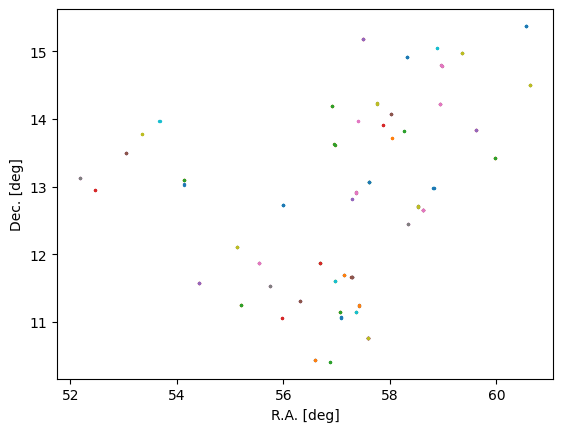

In [ ]:
#for i in range(len(r['ra3'])):
for i in range(100):
    x = [r['ra3'][i],r['ra'][i]]
    y = [r['dec3'][i],r['dec'][i]]
    plt.scatter(x,y,s=2)

plt.xlabel('R.A. [deg]')
plt.ylabel('Dec. [deg]')
#plt.xlim(56.55,56.65)
#plt.ylim(10.4,10.5)
plt.show()
plt.close()

In [ ]:
query = '''SELECT g3.source_id,
 g3.ra,
 g3.dec,
 aspar.mass_flame
FROM gaiadr3.gaia_source AS g3
JOIN gaiadr3.astrophysical_parameters as aspar
ON g3.source_id=aspar.source_id
'''
job = Gaia.launch_job_async(query=query)
r = job.get_results()
print(r.info)
tables.append(r)
Gaia.remove_jobs([job.jobid])

KeyboardInterrupt: 